In [1]:
# =====================================================
# 0. SETUP
# =====================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

if os.path.exists("/content/drive/MyDrive"):
    print("Google Drive already mounted")
else:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
%cd drive/MyDrive/UPF_Thesis/v4

/content/drive/MyDrive/UPF_Thesis/v4


In [3]:
pip install h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.6 MB/s eta 0:00:00


In [4]:
# =====================================================
# 1. IMPORT PROJECT CODE
# =====================================================

from src.feature_pipeline import ODFeaturePipeline

from src.models.wrappers import GeneratorWrapper
from src.models.vae import VAEModel
from src.models.wgan_gp import WGANModel
from src.models.bootstrap import BootstrapModel

from src.user_split import (
    load_and_filter_trip_data,
    build_user_summary,
    get_users_by_split,
    get_main_training_users,
    get_user_trips,
)

from src.attacks.shadow import (
    generate_shadow_splits,
    verify_shadow_labels,
    train_shadow_generators,
    verify_shadow_training_matches_labels,
)

from src.attacks.feature_table import build_feature_table
from src.attacks.attack_model import run_attack_evaluation

In [11]:
# =====================================================
# 2. CONFIG
# =====================================================

SEED = 42
DATA_PATH = "od_trips_20260410_input.csv"

UTILITY_FEATURE_COLS = [
    "duration_minutes",
    "centroid_dist",
    "start_centroid_lat",
    "start_centroid_lon",
    "end_centroid_lat",
    "end_centroid_lon",
]

MIA_FEATURE_COLS = [
    "min_od_distance",
    "p01_od_distance",
    "p05_od_distance",
    "p25_od_distance",
    "median_od_distance",
    "mean_od_distance",
    "std_od_distance",
    "close_trip_rate",
    "very_close_trip_rate",
    "duration_similarity",
    "distance_similarity",
    "od_overlap",
    "n_target_trips",
]

VAE_PARAMS = {
    "latent_dim": 32,
    "lr": 1e-3,
    "beta": 0.001,
}
VAE_TRAIN_PARAMS = {
    "epochs": 50, #100,      # increase later to 300
    "batch_size": 64,
    "val_size": 0.1,
    "random_state": SEED,
}

WGAN_PARAMS = {
    "noise_dim": 64,
    "hidden_dim": 128,
    "lr": 1e-4,
    "lambda_gp": 10.0,
    "critic_steps": 5,
}
WGAN_TRAIN_PARAMS = {
    "epochs": 50, #100,
    "batch_size": 64,
    "val_size": 0.1,
    "random_state": SEED,
}

BOOTSTRAP_PARAMS = {
    "random_state": SEED,
}
BOOTSTRAP_TRAIN_PARAMS = {
    "batch_size": 64,
}

N_SHADOW = 20
SHADOW_TRAIN_FRAC = 0.5

In [12]:
# =====================================================
# 3. LOAD DATA + SPLITS
# =====================================================

df = load_and_filter_trip_data(DATA_PATH)

user_summary = build_user_summary(
    df,
    user_col="user_id",
    duration_col="duration_minutes",
    distance_col="centroid_dist",
    test_size=0.2,
    shadow_size=0.5,
    random_state=SEED,
)

main_train_users = get_main_training_users(user_summary)
main_train_df = get_user_trips(df, main_train_users)

shadow_users = get_users_by_split(user_summary, "shadow")
eval_in_users = get_users_by_split(user_summary, "eval_in")
eval_out_users = get_users_by_split(user_summary, "eval_out")
eval_users = eval_in_users + eval_out_users

eval_user_trips = {
    user_id: get_user_trips(df, user_id)
    for user_id in eval_users
}

ground_truth_labels = {user_id: 1 for user_id in eval_in_users}
ground_truth_labels.update({user_id: 0 for user_id in eval_out_users})

shadow_user_trips = {
    user_id: get_user_trips(df, user_id)
    for user_id in shadow_users
}

pipeline = ODFeaturePipeline()
pipeline.fit(main_train_df)

Removed rows: 30
Percent removed: 0.39
activity_group
<10      67
10–20    29
21–63    29
64+      29
Name: count, dtype: int64


ODFeaturePipeline(start_lat_col='start_centroid_lat', start_lon_col='start_centroid_lon', end_lat_col='end_centroid_lat', end_lon_col='end_centroid_lon', duration_col='duration_minutes', distance_col='centroid_dist', time_col='start_time', duration_scaled_col='duration_scaled', distance_scaled_col='dist_scaled', coord_params={'cols': ['start_centroid_lat', 'start_centroid_lon', 'end_centroid_lat', 'end_centroid_lon'], 'means': start_centroid_lat     39.991705
start_centroid_lon    116.365973
end_centroid_lat       39.990549
end_centroid_lon      116.363993
dtype: float64, 'stds': start_centroid_lat    0.087535
start_centroid_lon    0.100597
end_centroid_lat      0.089158
end_centroid_lon      0.103651
dtype: float64}, duration_params={'mean': 3.0290151813115322, 'std': 0.7691224864587647}, distance_params={'mean': 9.343111432652915, 'std': 0.5049893929627884})

In [7]:
df

# Number of Trips

In [ ]:
# =====================================================
# Convert dataset times from UTC to Beijing local time
# =====================================================

TIME_COLS = ["start_time", "end_time"]

for col in TIME_COLS:
    df[col] = pd.to_datetime(df[col], errors="coerce")

    # Treat original timestamps as UTC, convert to Beijing,
    # then remove timezone info so the rest of the notebook uses local Beijing time.
    df[col] = (
        df[col]
        .dt.tz_localize("UTC")
        .dt.tz_convert("Asia/Shanghai")
        .dt.tz_localize(None)
    )

df[["start_time"]].head()

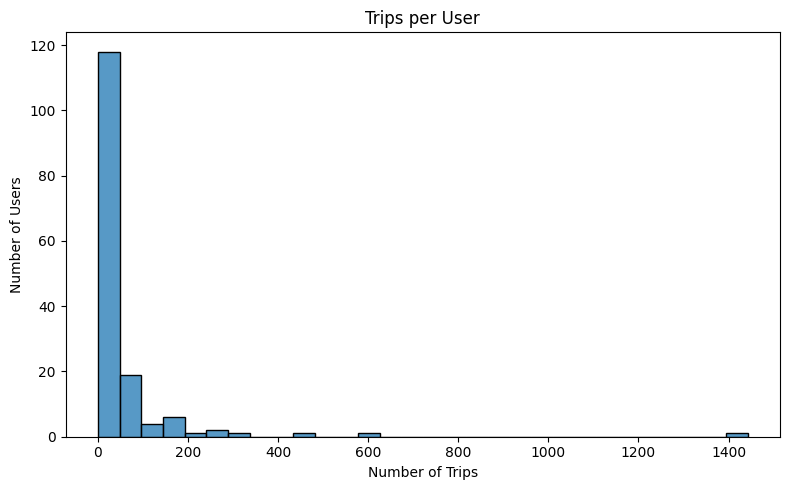

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

user_trip_counts = (
    df.groupby("user_id")
      .size()
      .reset_index(name="n_trips")
)

plt.figure(figsize=(8,5))

sns.histplot(
    data=user_trip_counts,
    x="n_trips",
    bins=30,
)

plt.title("Trips per User")
plt.xlabel("Number of Trips")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

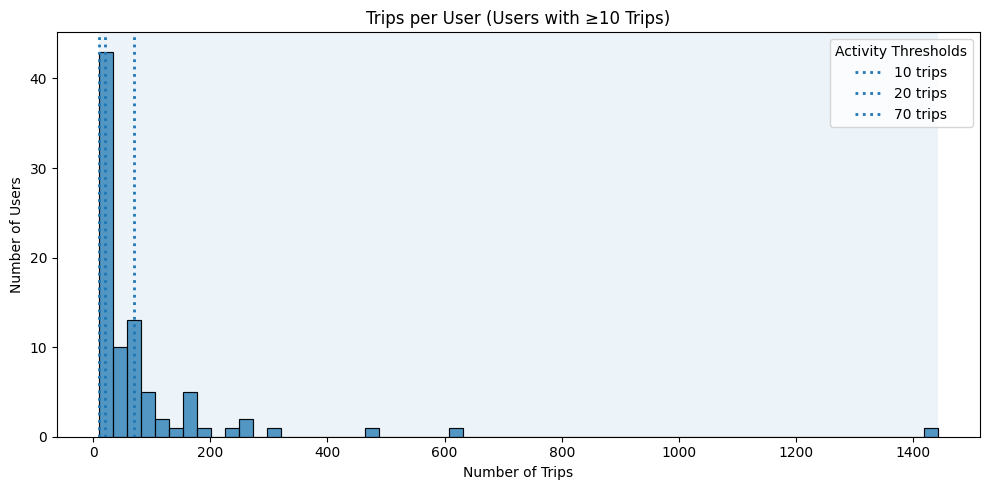

In [ ]:
# =====================================================
# Trips per User Histogram
# (excluding <10 trips users)
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

user_trip_counts = (
    df.groupby("user_id")
      .size()
      .reset_index(name="n_trips")
)

# remove low-activity users
plot_df = user_trip_counts[
    user_trip_counts["n_trips"] >= 10
]

plt.figure(figsize=(10, 5))

sns.histplot(
    data=plot_df,
    x="n_trips",
    bins=60,
)

# activity group boundaries
plt.axvline(10, linestyle="dotted", linewidth=2, label="10 trips")
plt.axvline(20, linestyle="dotted", linewidth=2, label="20 trips")
plt.axvline(70, linestyle="dotted", linewidth=2, label="70 trips")

# optional shaded regions for readability
plt.axvspan(10, 20, alpha=0.08)
plt.axvspan(20, 70, alpha=0.08)
plt.axvspan(70, plot_df["n_trips"].max(), alpha=0.08)

plt.title("Trips per User (Users with ≥10 Trips)")
plt.xlabel("Number of Trips")
plt.ylabel("Number of Users")

plt.legend(title="Activity Thresholds")

plt.tight_layout()
plt.show()

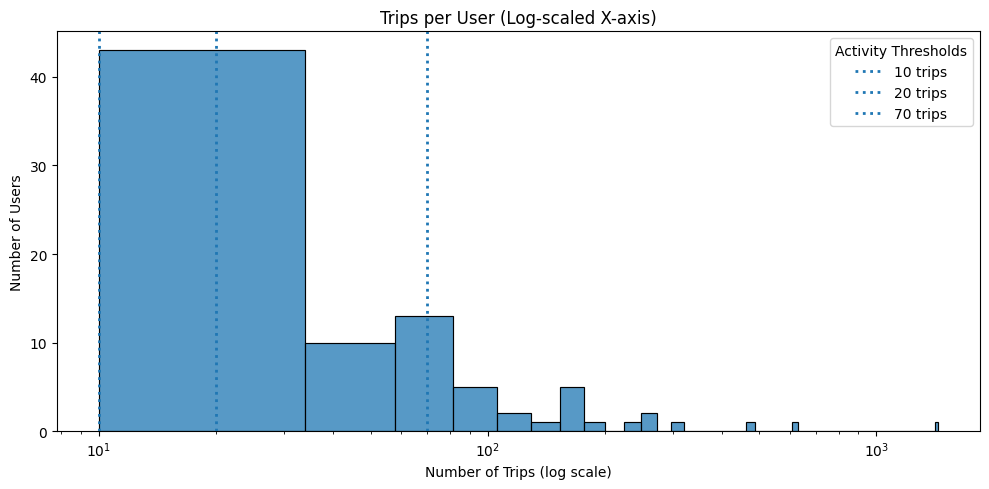

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

user_trip_counts = (
    df.groupby("user_id")
      .size()
      .reset_index(name="n_trips")
)

plot_df = user_trip_counts[
    user_trip_counts["n_trips"] >= 10
]

plt.figure(figsize=(10,5))

sns.histplot(
    data=plot_df,
    x="n_trips",
    bins=60
)

# activity thresholds
for threshold in [10, 20, 70]:
    plt.axvline(
        threshold,
        linestyle="dotted",
        linewidth=2,
        label=f"{threshold} trips"
    )

# logarithmic x-axis
plt.xscale("log")

plt.title("Trips per User (Log-scaled X-axis)")
plt.xlabel("Number of Trips (log scale)")
plt.ylabel("Number of Users")

plt.legend(title="Activity Thresholds")

plt.tight_layout()
plt.show()

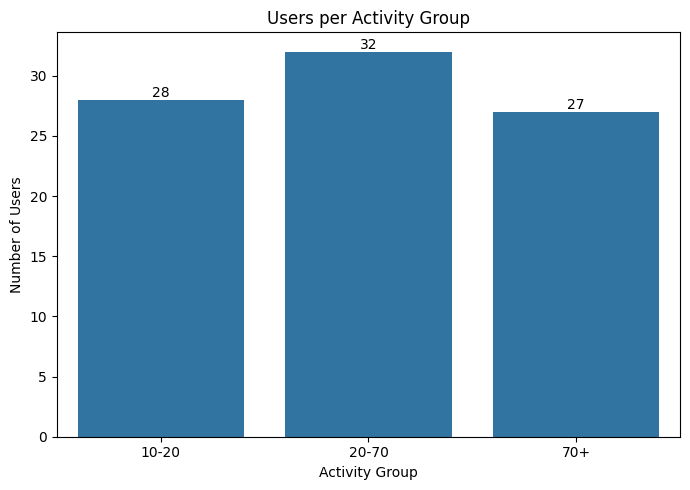

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

user_trip_counts = (
    df.groupby("user_id")
      .size()
      .reset_index(name="n_trips")
)

plot_df = user_trip_counts[
    user_trip_counts["n_trips"] >= 10
].copy()

plot_df["activity_group"] = pd.cut(
    plot_df["n_trips"],
    bins=[10, 20, 70, np.inf],
    labels=["10-20", "20-70", "70+"],
    right=False
)

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=plot_df,
    x="activity_group",
    order=["10-20", "20-70", "70+"]
)

# add labels above bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Users per Activity Group")
plt.xlabel("Activity Group")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

In [ ]:
def show_split(counts, edges, labels):
    g = pd.cut(counts, bins=edges, labels=labels, right=True, include_lowest=True)
    print(pd.DataFrame({
        "users": g.value_counts().sort_index(),
        "median_trips": counts.groupby(g, observed=True).median(),
    }).to_string())
    return g

ACTIVITY_BINS     = [-np.inf, 9, 20, 63, np.inf]
ACTIVITY_LABELS   = ["≤9", "Low (10–20)", "Medium (21–63)", "High (64+)"]
ACTIVITY_LABELS_NUMBERS   = ["<10", "10–20", "21–63", "64+"]
MIA_EXCLUDE_LABEL = "≤9"
_ = show_split(counts, ACTIVITY_BINS, ACTIVITY_LABELS)

NameError: name 'np' is not defined

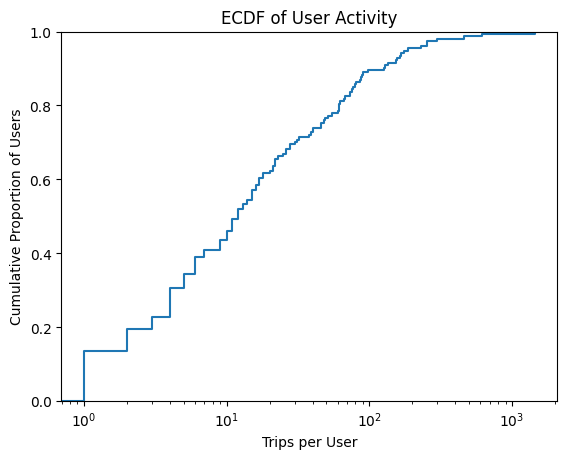

In [ ]:
sns.ecdfplot(
    data=user_trip_counts,
    x="n_trips"
)

plt.xscale("log")
plt.xlabel("Trips per User")
plt.ylabel("Cumulative Proportion of Users")
plt.title("ECDF of User Activity")
plt.show()

# Time of Trip

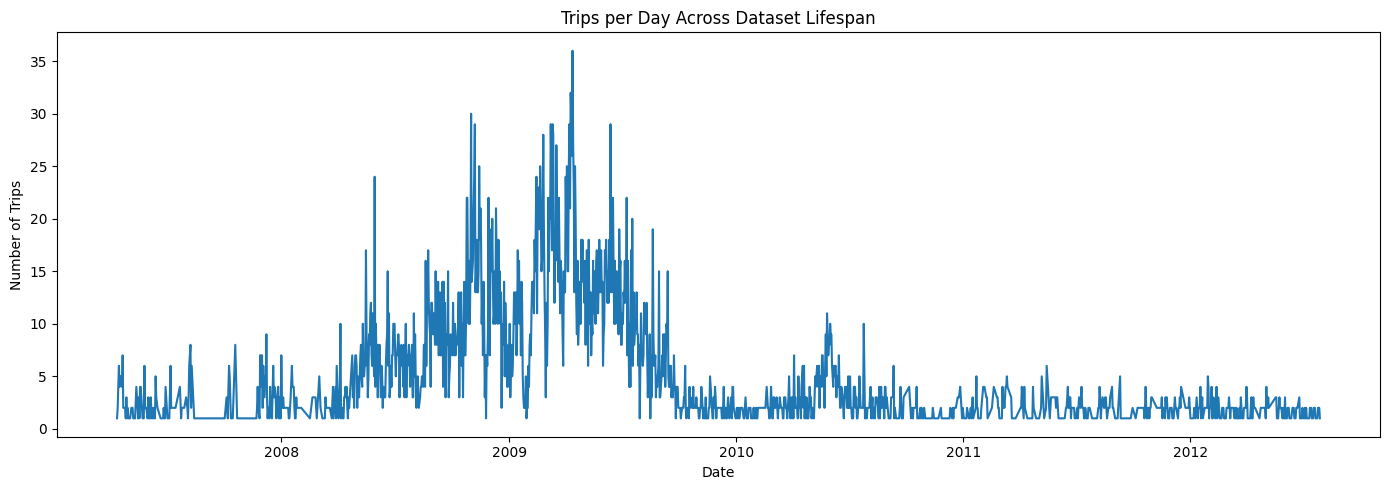

In [ ]:
df["start_time"] = pd.to_datetime(df["start_time"])

trips_per_day = (
    df.groupby(df["start_time"].dt.date)
      .size()
)

plt.figure(figsize=(14,5))

trips_per_day.plot()

plt.title("Trips per Day Across Dataset Lifespan")
plt.xlabel("Date")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()

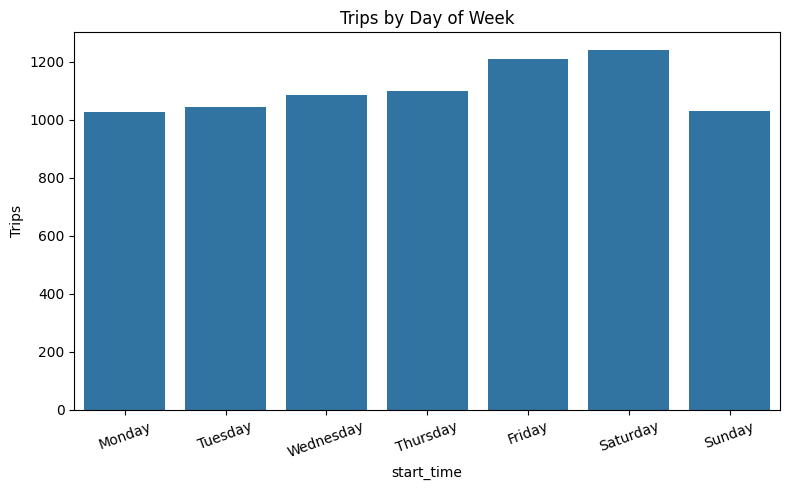

In [ ]:
weekday_counts = (
    df["start_time"]
      .dt.day_name()
      .value_counts()
      .reindex([
          "Monday",
          "Tuesday",
          "Wednesday",
          "Thursday",
          "Friday",
          "Saturday",
          "Sunday"
      ])
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=weekday_counts.index,
    y=weekday_counts.values
)

plt.title("Trips by Day of Week")
plt.ylabel("Trips")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

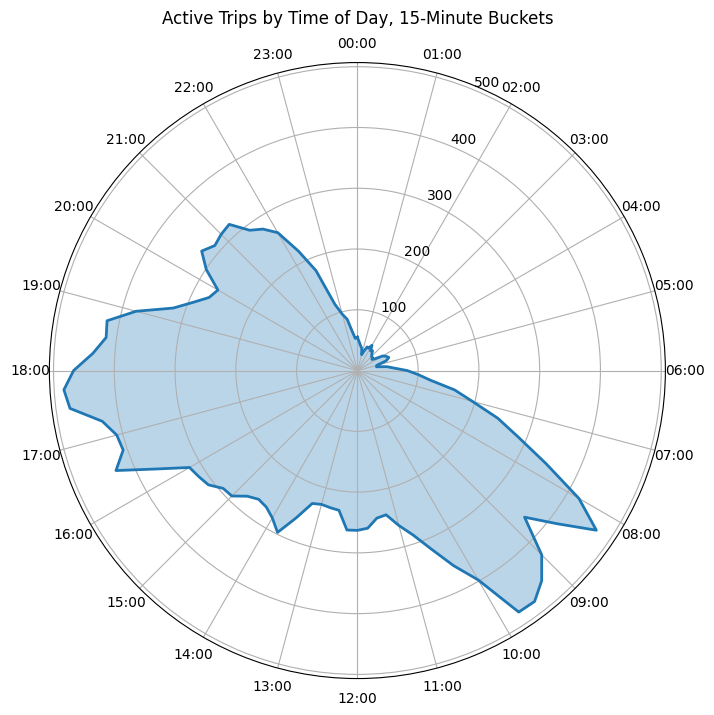

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# make sure times are datetime
df["start_time"] = pd.to_datetime(df["start_time"])

# calculate end time from duration
df["end_time"] = df["start_time"] + pd.to_timedelta(df["duration_minutes"], unit="m")

# 30-minute buckets across a day
bin_minutes = 15
n_bins = int(24 * 60 / bin_minutes)

active_counts = np.zeros(n_bins)

for _, row in df.iterrows():
    start_minutes = row["start_time"].hour * 60 + row["start_time"].minute
    end_minutes = row["end_time"].hour * 60 + row["end_time"].minute

    start_bin = start_minutes // bin_minutes
    end_bin = end_minutes // bin_minutes

    # same-day trip
    if row["end_time"].date() == row["start_time"].date():
        active_bins = range(start_bin, end_bin + 1)

    # trip crosses midnight
    else:
        active_bins = list(range(start_bin, n_bins)) + list(range(0, end_bin + 1))

    for b in active_bins:
        active_counts[b] += 1

# angles for polar plot
bins = np.arange(n_bins)
angles = 2 * np.pi * bins / n_bins

# close the loop
angles = np.concatenate([angles, [angles[0]]])
active_counts = np.concatenate([active_counts, [active_counts[0]]])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

ax.plot(angles, active_counts, linewidth=2)
ax.fill(angles, active_counts, alpha=0.3)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# show labels every hour
hour_ticks = np.arange(0, n_bins, 4)
ax.set_xticks(2 * np.pi * hour_ticks / n_bins)
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)])

plt.title("Active Trips by Time of Day, 15-Minute Buckets", loc="center",
          y=1.05)
plt.show()

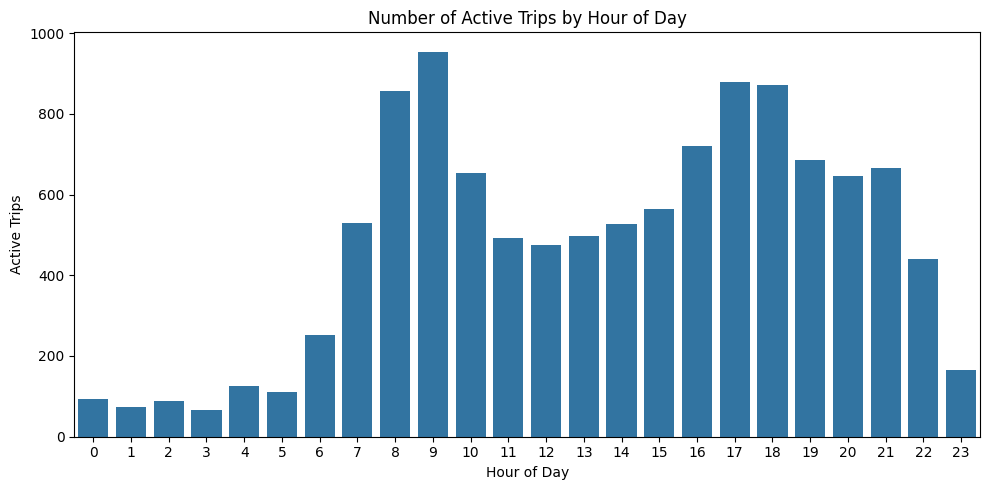

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# -----------------------------------------
# Count active trips per hour
# -----------------------------------------

active_counts = np.zeros(24)

for _, row in df.iterrows():

    start_hour = row["start_time"].hour
    end_hour = row["end_time"].hour

    # approximate occupied hours
    if end_hour >= start_hour:
        hours_active = range(start_hour, end_hour + 1)
    else:
        # overnight wraparound
        hours_active = list(range(start_hour, 24)) + list(range(0, end_hour + 1))

    for h in hours_active:
        active_counts[h] += 1

# -----------------------------------------
# Plot
# -----------------------------------------

plt.figure(figsize=(10,5))

sns.barplot(
    x=list(range(24)),
    y=active_counts
)

plt.title("Number of Active Trips by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Active Trips")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

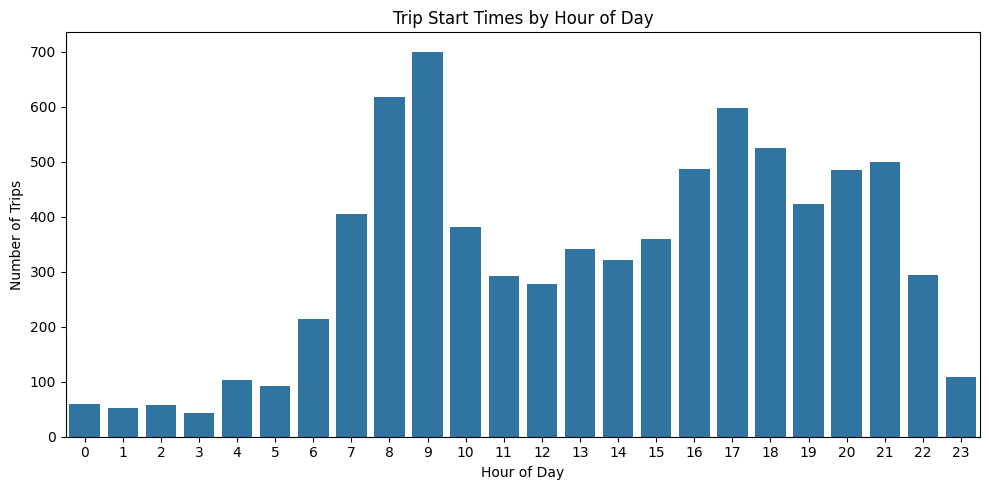

In [ ]:
df["start_time"] = pd.to_datetime(df["start_time"])

hour_counts = (
    df["start_time"]
      .dt.hour
      .value_counts()
      .reindex(range(24), fill_value=0)
      .sort_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=hour_counts.index,
    y=hour_counts.values
)

plt.title("Trip Start Times by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [ ]:
df

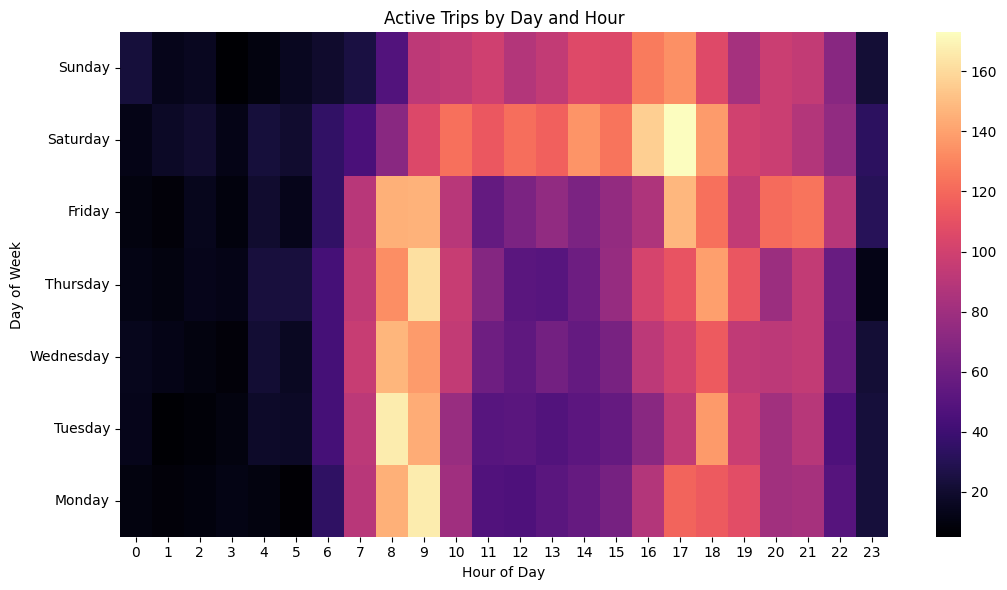

In [ ]:
active_rows = []

for _, row in df.iterrows():

    start = row["start_time"]
    end = row["end_time"]

    current = start.floor("h")

    while current <= end:

        active_rows.append({
            "day": current.day_name(),
            "hour": current.hour
        })

        current += pd.Timedelta(hours=1)

active_df = pd.DataFrame(active_rows)

pivot = pd.pivot_table(
    active_df,
    index="day",
    columns="hour",
    aggfunc="size",
    fill_value=0
)

# order days
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

pivot = pivot.reindex(day_order[::-1])

plt.figure(figsize=(11, 6))

sns.heatmap(
    pivot,
    cmap="magma"
)

plt.title("Active Trips by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

<Axes: xlabel='duration_minutes', ylabel='centroid_dist'>

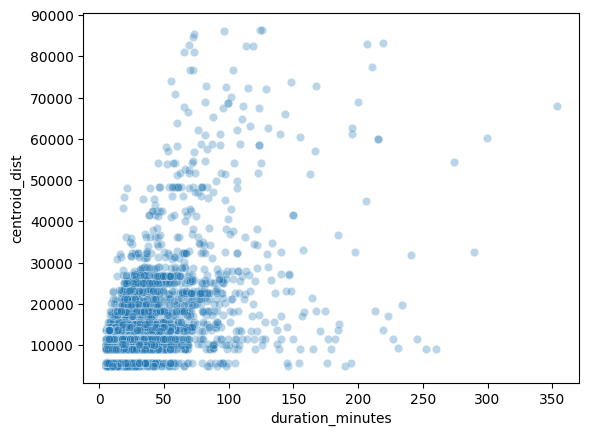

In [ ]:
sns.scatterplot(
    data=df.sample(min(len(df), 5000)),
    x="duration_minutes",
    y="centroid_dist",
    alpha=0.3
)

# Coordinates

In [8]:
!pip install contextily

In [9]:
ls gadm41_CHN_1.json.zip

gadm41_CHN_1.json.zip


In [14]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
from collections import Counter
import h3

# =========================================
# Build combined OD H3 activity
# =========================================

H3_RES = 6

# origin + destination hexes
all_hexes = []

for _, row in df.iterrows():

    start_hex = h3.latlng_to_cell(
        row["start_centroid_lat"],
        row["start_centroid_lon"],
        H3_RES
    )

    end_hex = h3.latlng_to_cell(
        row["end_centroid_lat"],
        row["end_centroid_lon"],
        H3_RES
    )

    all_hexes.extend([start_hex, end_hex])

# count activity
hex_counts = Counter(all_hexes)

# =========================================
# Convert H3 cells into polygons
# =========================================

hex_rows = []

for hex_id, count in hex_counts.items():

    boundary = h3.cell_to_boundary(hex_id)

    polygon = Polygon([
        (lng, lat) for lat, lng in boundary
    ])

    hex_rows.append({
        "h3_cell": hex_id,
        "activity_count": count,
        "geometry": polygon
    })

gdf_hex = gpd.GeoDataFrame(
    hex_rows,
    geometry="geometry",
    crs="EPSG:4326"
)

gdf_hex.head()

,h3_cell,activity_count,geometry
0,8631aa42fffffff,425,"POLYGON ((116.37895 39.93097, 116.36266 39.902..."
1,8631aa427ffffff,579,"POLYGON ((116.32494 39.94856, 116.30866 39.920..."
2,8631aa52fffffff,782,"POLYGON ((116.31973 40.05111, 116.30342 40.022..."
3,8631aa50fffffff,3511,"POLYGON ((116.32234 39.99982, 116.30604 39.971..."
4,8631aa507ffffff,1182,"POLYGON ((116.26819 40.01744, 116.2519 39.9891..."


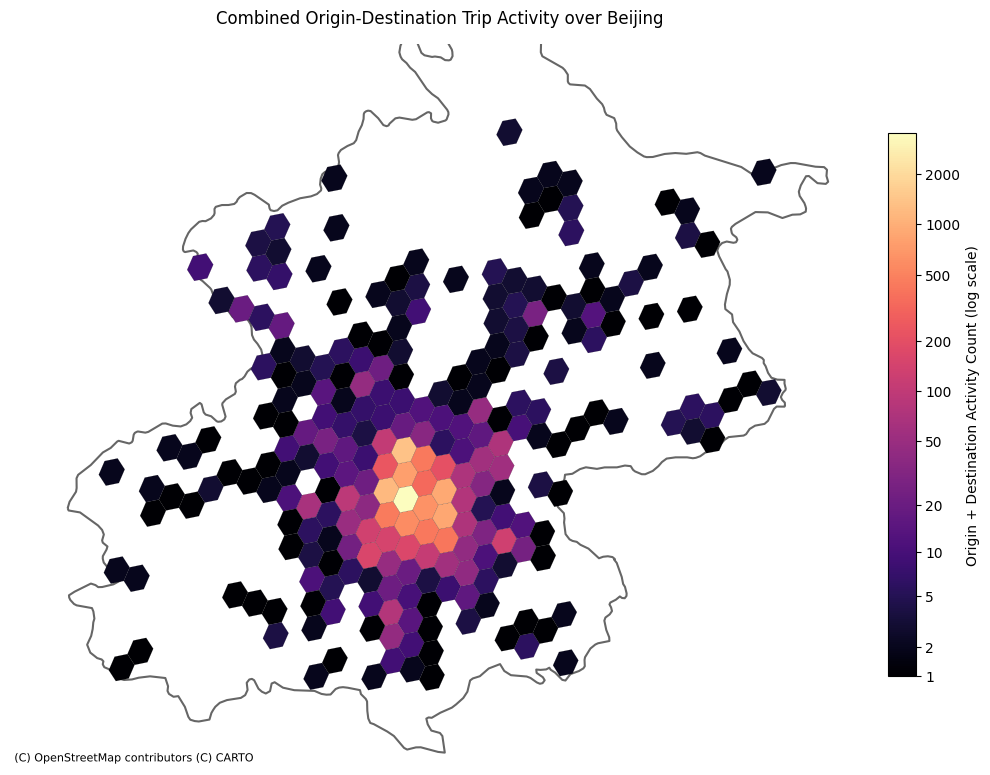

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
import matplotlib.colors as colors
import matplotlib.cm as cm

# Path to Beijing boundary zip/json
BEIJING_BOUNDARY_PATH = "gadm41_CHN_1.json.zip"

# Read Beijing boundary
china_admin1 = gpd.read_file(f"zip://{BEIJING_BOUNDARY_PATH}")

beijing = china_admin1[
    china_admin1["NAME_1"].str.contains("Beijing", case=False, na=False)
].copy()

# Reproject to Web Mercator for contextily basemap
gdf_web = gdf_hex.to_crs(epsg=3857)
beijing_web = beijing.to_crs(epsg=3857)

# Log scale for colour, but legend uses original counts
gdf_web["log_activity"] = np.log1p(gdf_web["activity_count"])

fig, ax = plt.subplots(figsize=(10, 10))

# Faded Beijing outline / polygon
beijing_web.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.5,
    alpha=0.6
)

# Transparent H3 usage layer
gdf_web.plot(
    column="log_activity",
    ax=ax,
    cmap="magma",
    alpha=1,
    edgecolor="black",
    linewidth=0.08
)

# Faded basemap underneath
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels,
    alpha=0
)

# Keep view around Beijing hexes/boundary
minx, miny, maxx, maxy = gdf_web.total_bounds
width = maxx - minx
height = maxy - miny

pad_x = width * 0.13
pad_y = height * 0.13

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)



ax.set_title("Combined Origin-Destination Trip Activity over Beijing", pad=15)
ax.set_axis_off()

# Custom colourbar with original activity counts
norm = colors.Normalize(
    vmin=gdf_web["log_activity"].min(),
    vmax=gdf_web["log_activity"].max()
)

sm = cm.ScalarMappable(
    norm=norm,
    cmap="magma"
)

sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)

tick_counts = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]
tick_counts = [t for t in tick_counts if t <= gdf_web["activity_count"].max()]

cbar.set_ticks(np.log1p(tick_counts))
cbar.set_ticklabels(tick_counts)
cbar.set_label("Origin + Destination Activity Count (log scale)")

plt.tight_layout()
plt.show()

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geopandas as gpd
from shapely.geometry import Polygon
from collections import Counter
import h3

# =====================================================
# Config
# =====================================================

SYNTH_DIR = "outputs/synth"
SEEDS = [111, 222, 333, 444]

MODEL_FILES = {
    "Bootstrap": "bootstrap_seed_{seed}.csv",
    "VAE": "vae_seed_{seed}.csv",
    "WGAN-GP": "wgan_gp_seed_{seed}.csv",
}

H3_RES = 6

# Hardcoded to match first image scale: activity count 1–2000
NORM = colors.Normalize(
    vmin=np.log1p(1),
    vmax=np.log1p(6000)
)

# =====================================================
# Helper: dataframe → H3 activity GeoDataFrame
# =====================================================

def build_h3_activity(df, h3_res=6):
    all_hexes = []

    for _, row in df.iterrows():
        start_hex = h3.latlng_to_cell(
            row["start_centroid_lat"],
            row["start_centroid_lon"],
            h3_res
        )

        end_hex = h3.latlng_to_cell(
            row["end_centroid_lat"],
            row["end_centroid_lon"],
            h3_res
        )

        all_hexes.extend([start_hex, end_hex])

    hex_counts = Counter(all_hexes)

    rows = []

    for hex_id, count in hex_counts.items():
        boundary = h3.cell_to_boundary(hex_id)

        polygon = Polygon([
            (lng, lat) for lat, lng in boundary
        ])

        rows.append({
            "h3_cell": hex_id,
            "activity_count": count,
            "geometry": polygon
        })

    gdf = gpd.GeoDataFrame(
        rows,
        geometry="geometry",
        crs="EPSG:4326"
    )

    gdf["log_activity"] = np.log1p(gdf["activity_count"])

    return gdf.to_crs(epsg=3857)


# =====================================================
# Beijing boundary
# =====================================================

BEIJING_BOUNDARY_PATH = "gadm41_CHN_1.json.zip"

china_admin1 = gpd.read_file(f"zip://{BEIJING_BOUNDARY_PATH}")

beijing = china_admin1[
    china_admin1["NAME_1"].str.contains("Beijing", case=False, na=False)
].copy()

beijing_web = beijing.to_crs(epsg=3857)

# Use real data bounds so all maps have same viewing window
real_gdf = build_h3_activity(df, H3_RES)

minx, miny, maxx, maxy = real_gdf.total_bounds
width = maxx - minx
height = maxy - miny
pad_x = width * 0.13
pad_y = height * 0.13

xlim = (minx - pad_x, maxx + pad_x)
ylim = (miny - pad_y, maxy + pad_y)

In [20]:
ls artifacts_v4

Bootstrap/  splits/  VAE/  WGAN_GP/


In [21]:
ls artifacts_v4/VAE

vae_seed111__attack_df.csv
vae_seed111__attack_model.pkl
vae_seed111.csv
vae_seed111__distance_privacy_by_group.csv
vae_seed111__mia_results.csv
vae_seed111__utility_by_group.csv
vae_seed222__attack_df.csv
vae_seed222__attack_model.pkl
vae_seed222.csv
vae_seed222__distance_privacy_by_group.csv
vae_seed222__mia_results.csv
vae_seed222__utility_by_group.csv
vae_seed333__attack_df.csv
vae_seed333__attack_model.pkl
vae_seed333.csv
vae_seed333__distance_privacy_by_group.csv
vae_seed333__mia_results.csv
vae_seed333__utility_by_group.csv
vae_seed444__attack_df.csv
vae_seed444__attack_model.pkl
vae_seed444.csv
vae_seed444__distance_privacy_by_group.csv
vae_seed444__mia_results.csv
vae_seed444__utility_by_group.csv
vae_seed555__attack_df.csv
vae_seed555__attack_model.pkl
vae_seed555.csv
vae_seed555__distance_privacy_by_group.csv
vae_seed555__mia_results.csv
vae_seed555__utility_by_group.csv


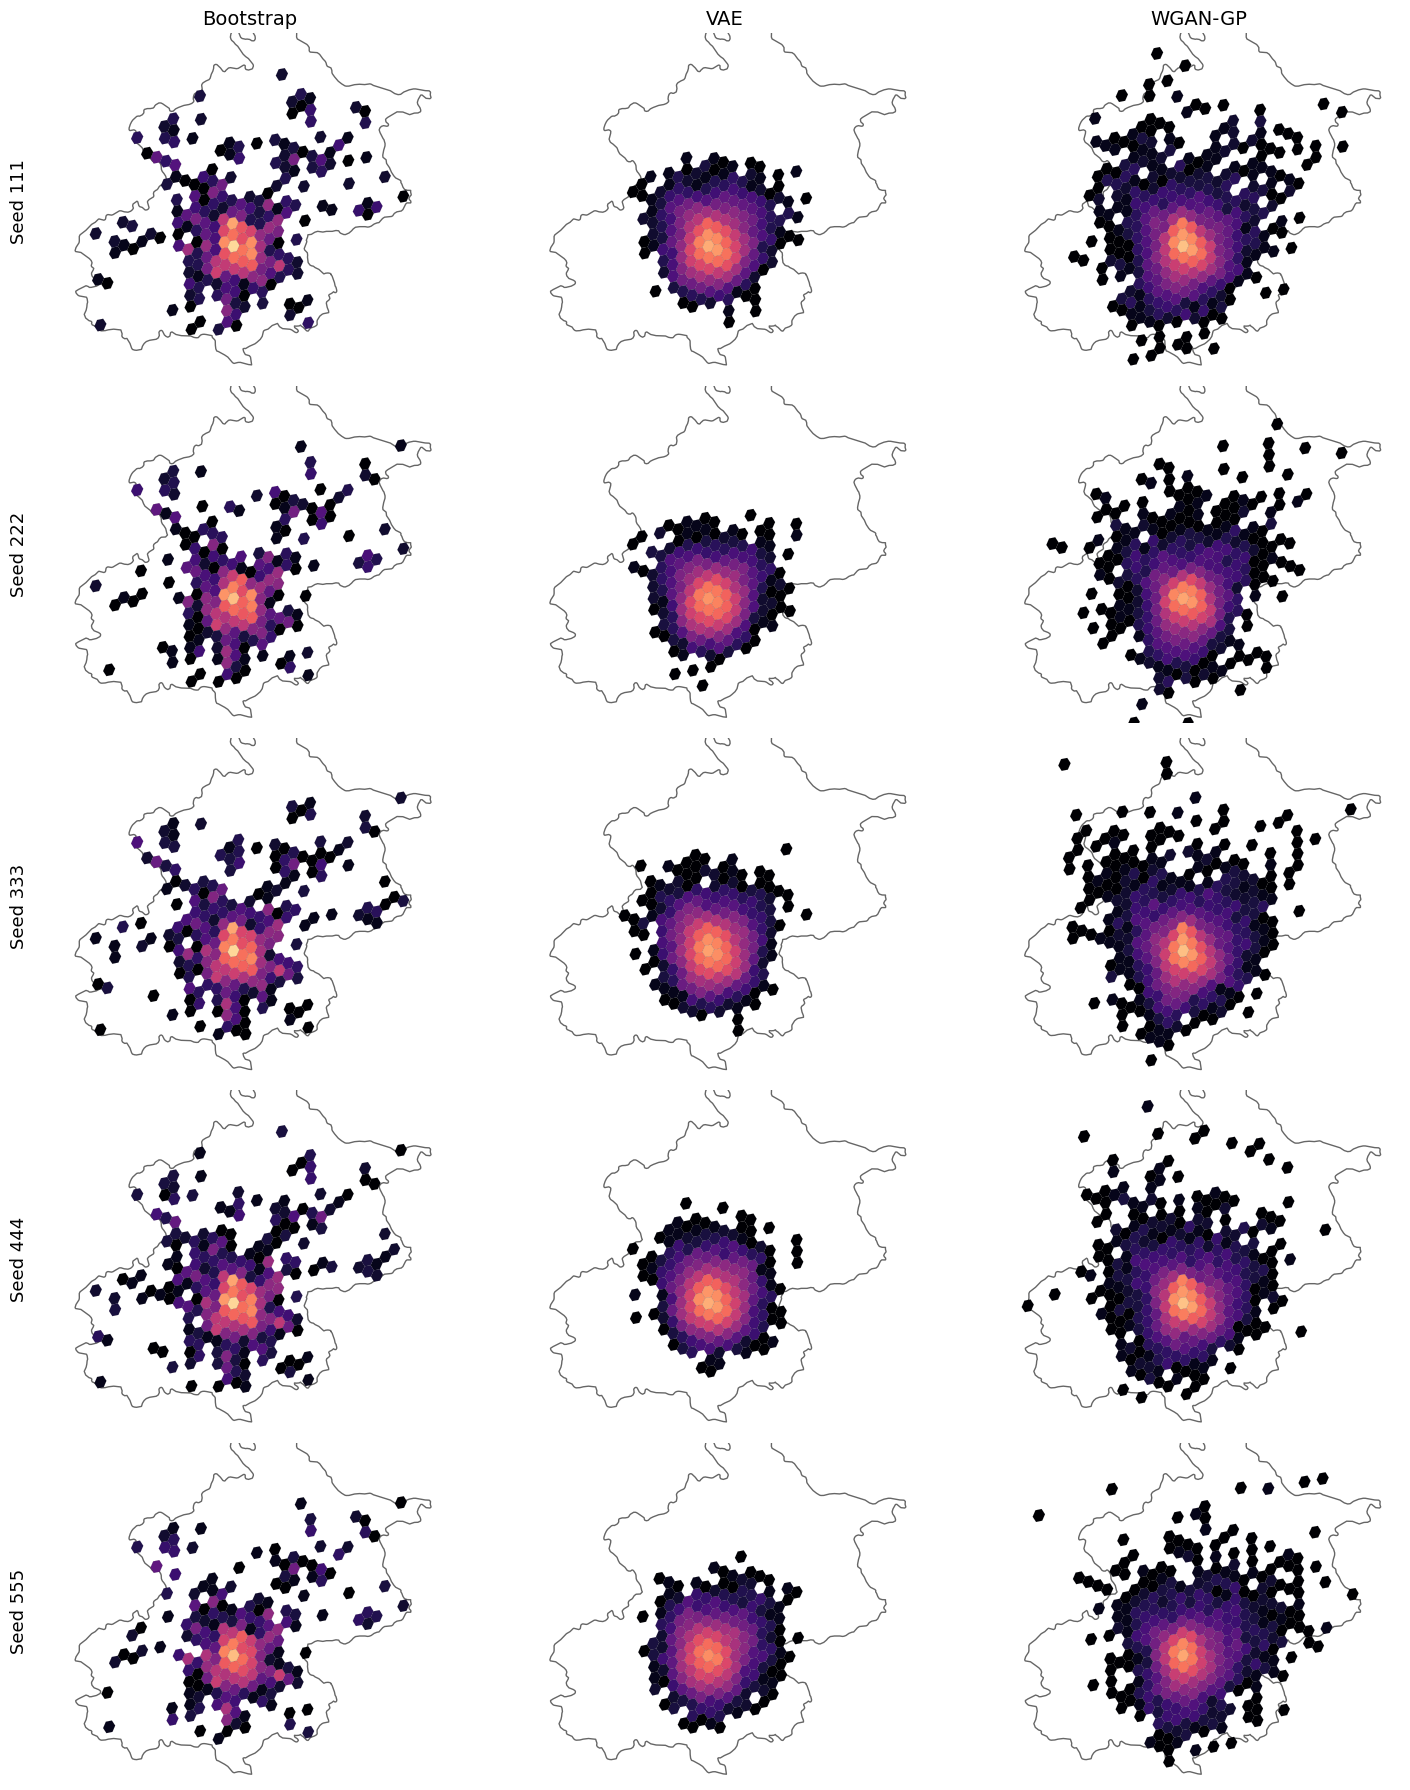

In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geopandas as gpd
from shapely.geometry import Polygon
from collections import Counter
import h3

# =====================================================
# Config
# =====================================================

SYNTH_DIR = "artifacts_v4"
SEEDS = [111, 222, 333, 444, 555]

MODEL_FILES = {
    "Bootstrap": "Bootstrap/bootstrap_seed{seed}.csv",
    "VAE": "VAE/vae_seed{seed}.csv",
    "WGAN-GP": "WGAN_GP/wgan_gp_seed{seed}.csv",
}

H3_RES = 6

# Hardcoded to match first image scale: activity count 1–2000
NORM = colors.Normalize(
    vmin=np.log1p(1),
    vmax=np.log1p(6000)
)

# =====================================================
# Helper: dataframe → H3 activity GeoDataFrame
# =====================================================

def build_h3_activity(df, h3_res=6):
    all_hexes = []

    for _, row in df.iterrows():
        start_hex = h3.latlng_to_cell(
            row["start_centroid_lat"],
            row["start_centroid_lon"],
            h3_res
        )

        end_hex = h3.latlng_to_cell(
            row["end_centroid_lat"],
            row["end_centroid_lon"],
            h3_res
        )

        all_hexes.extend([start_hex, end_hex])

    hex_counts = Counter(all_hexes)

    rows = []

    for hex_id, count in hex_counts.items():
        boundary = h3.cell_to_boundary(hex_id)

        polygon = Polygon([
            (lng, lat) for lat, lng in boundary
        ])

        rows.append({
            "h3_cell": hex_id,
            "activity_count": count,
            "geometry": polygon
        })

    gdf = gpd.GeoDataFrame(
        rows,
        geometry="geometry",
        crs="EPSG:4326"
    )

    gdf["log_activity"] = np.log1p(gdf["activity_count"])

    return gdf.to_crs(epsg=3857)


# =====================================================
# Beijing boundary
# =====================================================

BEIJING_BOUNDARY_PATH = "gadm41_CHN_1.json.zip"

china_admin1 = gpd.read_file(f"zip://{BEIJING_BOUNDARY_PATH}")

beijing = china_admin1[
    china_admin1["NAME_1"].str.contains("Beijing", case=False, na=False)
].copy()

beijing_web = beijing.to_crs(epsg=3857)

# Use real data bounds so all maps have same viewing window
real_gdf = build_h3_activity(df, H3_RES)

minx, miny, maxx, maxy = real_gdf.total_bounds
width = maxx - minx
height = maxy - miny
pad_x = width * 0.13
pad_y = height * 0.13

xlim = (minx - pad_x, maxx + pad_x)
ylim = (miny - pad_y, maxy + pad_y)

# =====================================================
# Plot 4 x 3 grid
# =====================================================

fig, axes = plt.subplots(
    len(SEEDS),
    len(MODEL_FILES),
    figsize=(15, 18)
)

for row_idx, seed in enumerate(SEEDS):
    for col_idx, (model_name, file_pattern) in enumerate(MODEL_FILES.items()):

        ax = axes[row_idx, col_idx]

        path = os.path.join(
            SYNTH_DIR,
            file_pattern.format(seed=seed)
        )

        synth_df = pd.read_csv(path)
        gdf_plot = build_h3_activity(synth_df, H3_RES)

        beijing_web.plot(
            ax=ax,
            facecolor="none",
            edgecolor="black",
            linewidth=1,
            alpha=0.6
        )

        gdf_plot.plot(
            column="log_activity",
            ax=ax,
            cmap="magma",
            norm=NORM,
            edgecolor="black",
            linewidth=0.05
        )

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_axis_off()

        if row_idx == 0:
            ax.set_title(model_name, fontsize=14)

        if col_idx == 0:
            ax.text(
                -0.05,
                0.5,
                f"Seed {seed}",
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="right",
                fontsize=13
            )

#fig.suptitle(
#   "Synthetic Origin-Destination Activity by Model and Seed",
#    fontsize=18,
#    y=0.92
#)

plt.tight_layout()
plt.show()

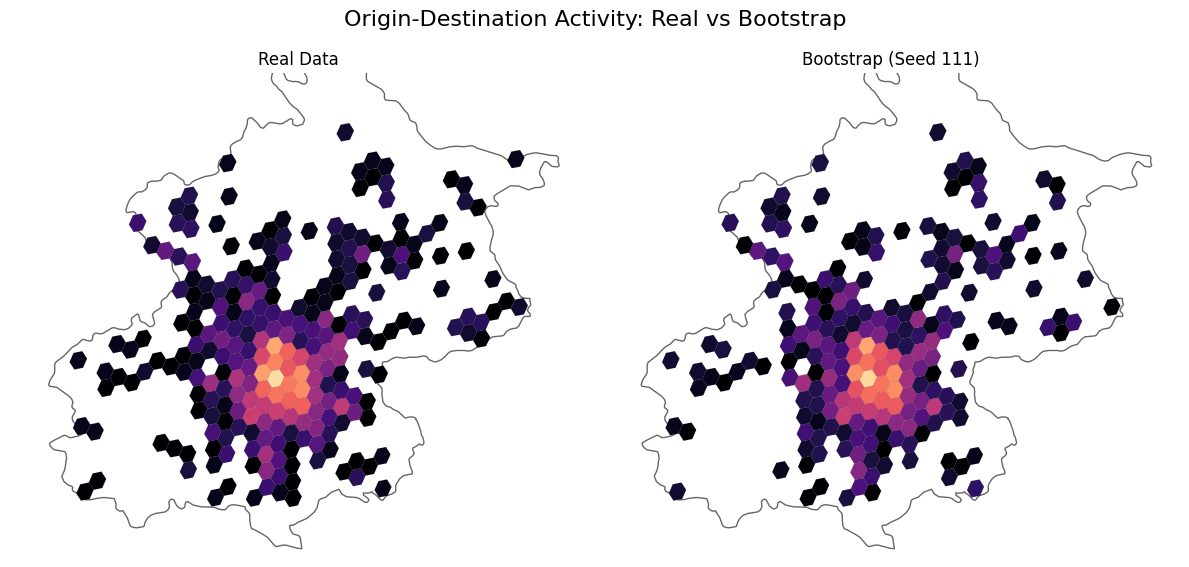

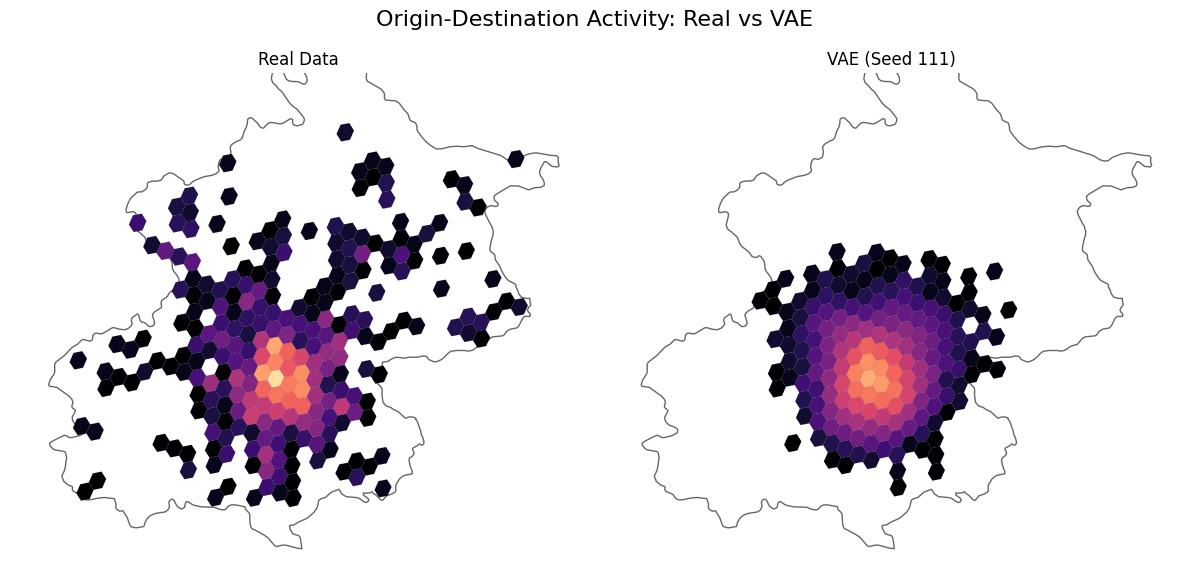

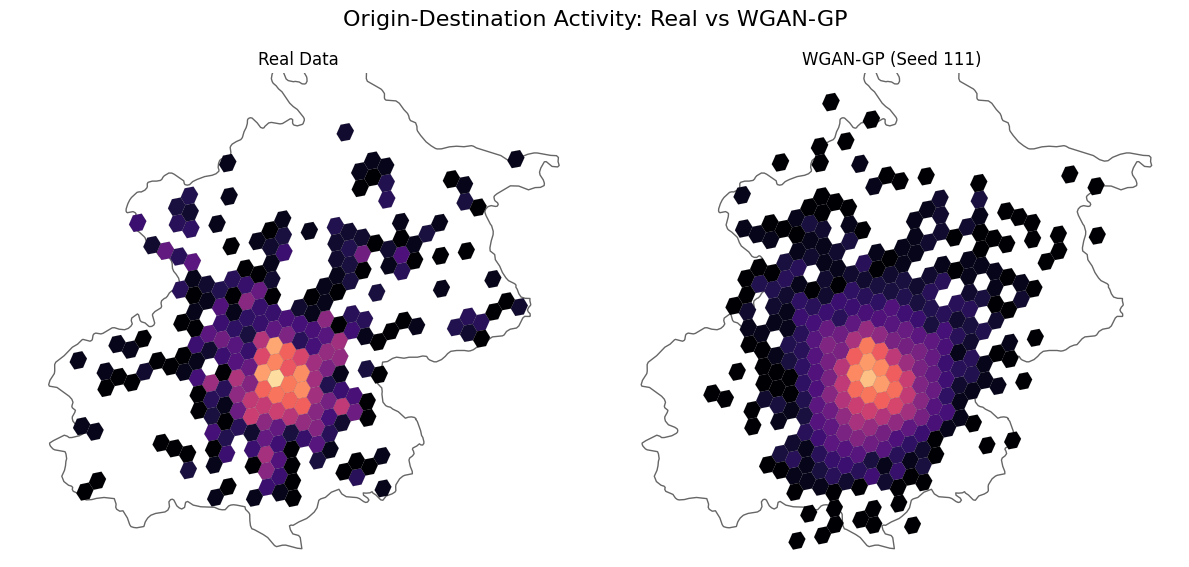

In [27]:
# =====================================================
# Real vs Seed111 comparison for each model
# =====================================================

MODELS = {
    "Bootstrap": "artifacts_v4/Bootstrap/bootstrap_seed111.csv",
    "VAE": "artifacts_v4/VAE/vae_seed111.csv",
    "WGAN-GP": "artifacts_v4/WGAN_GP/wgan_gp_seed111.csv",
}

for model_name, path in MODELS.items():

    synth_df = pd.read_csv(path)
    synth_gdf = build_h3_activity(synth_df, H3_RES)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 6)
    )

    # ----------------------------
    # Real
    # ----------------------------
    beijing_web.plot(
        ax=axes[0],
        facecolor="none",
        edgecolor="black",
        linewidth=1,
        alpha=0.6
    )

    real_gdf.plot(
        column="log_activity",
        ax=axes[0],
        cmap="magma",
        norm=NORM,
        edgecolor="black",
        linewidth=0.05
    )

    axes[0].set_xlim(*xlim)
    axes[0].set_ylim(*ylim)
    axes[0].set_axis_off()
    axes[0].set_title("Real Data")

    # ----------------------------
    # Synthetic
    # ----------------------------
    beijing_web.plot(
        ax=axes[1],
        facecolor="none",
        edgecolor="black",
        linewidth=1,
        alpha=0.6
    )

    synth_gdf.plot(
        column="log_activity",
        ax=axes[1],
        cmap="magma",
        norm=NORM,
        edgecolor="black",
        linewidth=0.05
    )

    axes[1].set_xlim(*xlim)
    axes[1].set_ylim(*ylim)
    axes[1].set_axis_off()
    axes[1].set_title(f"{model_name} (Seed 111)")

    plt.suptitle(
        f"Origin-Destination Activity: Real vs {model_name}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

In [29]:
synth_df

,start_centroid_lat,start_centroid_lon,end_centroid_lat,end_centroid_lon,duration_minutes,centroid_dist,hour,day_of_week
0,39.819369,116.305363,40.110619,116.452256,40.070732,33497.5740,7.900500,6.690608
1,39.945689,116.452278,39.947861,116.308850,41.229397,11905.6500,9.125854,2.856581
2,39.902752,116.332294,39.957875,116.359837,11.512399,9102.8120,6.657226,5.111768
3,39.984356,116.315230,40.092267,116.350187,30.505585,11166.2295,12.829734,5.018777
4,39.936918,116.332055,39.890290,116.438876,7.699389,6877.3430,12.148334,4.088535
...,...,...,...,...,...,...,...,...
6812,39.945824,116.415209,39.946508,116.352499,67.554115,7056.2764,8.433128,4.962876
6813,40.005091,116.340628,40.065597,116.340667,23.904186,10635.2800,9.171669,3.373445
6814,39.900247,116.323827,40.046234,116.307396,12.398795,15846.2705,9.575144,5.681529
6815,39.997750,116.384911,40.026506,116.638098,14.781083,18763.5100,4.877972,2.328961


In [31]:
df.columns

Index(['trip_id', 'user_id', 'session_id', 'start_time', 'end_time',
       'duration_minutes', 'start_hex', 'end_hex', 'n_points', 'inter_hex_num',
       'avg_gps_splits', 'traj_start_lat', 'traj_start_lon', 'traj_end_lat',
       'traj_end_lon', 'traj_dist_m', 'mode', 'start_centroid_lat',
       'start_centroid_lon', 'end_centroid_lat', 'end_centroid_lon',
       'centroid_dist', 'centroid_speed_kmh'],
      dtype='object')

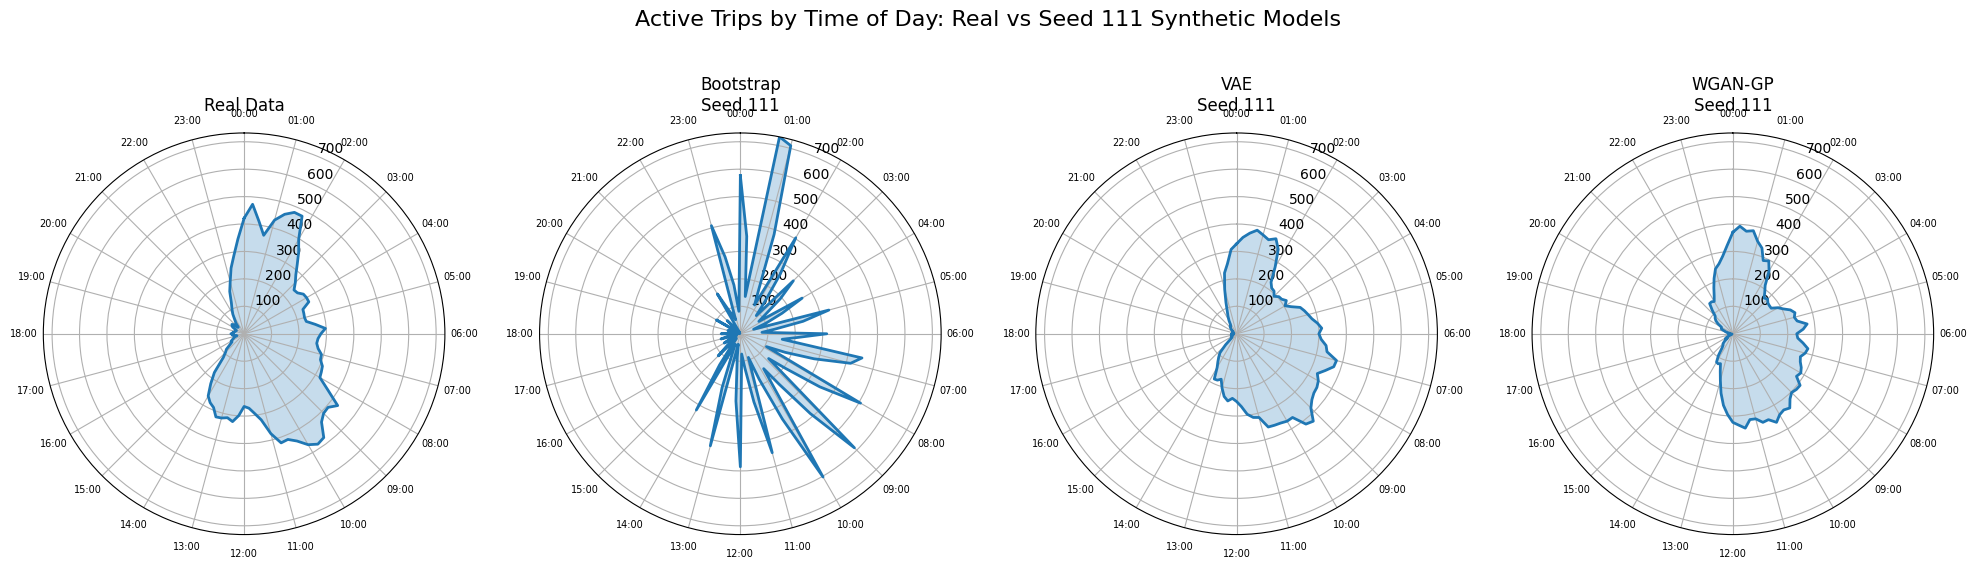

In [32]:
# =====================================================
# Active-hours wagon wheel: Real vs Seed111 models
# Uses start_time/end_time if available,
# otherwise reconstructs from hour + duration_minutes
# =====================================================

MODELS = {
    "Real Data": None,
    "Bootstrap\nSeed 111": "artifacts_v4/Bootstrap/bootstrap_seed111.csv",
    "VAE\nSeed 111": "artifacts_v4/VAE/vae_seed111.csv",
    "WGAN-GP\nSeed 111": "artifacts_v4/WGAN_GP/wgan_gp_seed111.csv",
}

BIN_MINUTES = 15
N_BINS = int(24 * 60 / BIN_MINUTES)

def get_active_trip_counts(data, bin_minutes=15):
    plot_df = data.copy()
    n_bins = int(24 * 60 / bin_minutes)
    active_counts = np.zeros(n_bins)

    # Real data path: timestamps exist
    if "start_time" in plot_df.columns:
        plot_df["start_time"] = pd.to_datetime(plot_df["start_time"], errors="coerce")

        if "end_time" in plot_df.columns:
            plot_df["end_time"] = pd.to_datetime(plot_df["end_time"], errors="coerce")
        else:
            plot_df["end_time"] = (
                plot_df["start_time"]
                + pd.to_timedelta(plot_df["duration_minutes"], unit="m")
            )

        for _, row in plot_df.dropna(subset=["start_time", "end_time"]).iterrows():
            start_minutes = row["start_time"].hour * 60 + row["start_time"].minute
            end_minutes = row["end_time"].hour * 60 + row["end_time"].minute

            start_bin = int(start_minutes // bin_minutes)
            end_bin = int(end_minutes // bin_minutes)

            if row["end_time"].date() == row["start_time"].date():
                active_bins = range(start_bin, min(end_bin + 1, n_bins))
            else:
                active_bins = list(range(start_bin, n_bins)) + list(range(0, min(end_bin + 1, n_bins)))

            for b in active_bins:
                active_counts[b] += 1

    # Synthetic path: generated hour column exists
    else:
        plot_df = plot_df.dropna(subset=["hour", "duration_minutes"])

        for _, row in plot_df.iterrows():
            start_minutes = float(row["hour"]) * 60
            duration_minutes = max(float(row["duration_minutes"]), 0)

            end_minutes = start_minutes + duration_minutes

            start_bin = int(start_minutes // bin_minutes) % n_bins
            end_bin = int(end_minutes // bin_minutes) % n_bins

            if end_minutes < 24 * 60:
                active_bins = range(start_bin, min(end_bin + 1, n_bins))
            else:
                active_bins = list(range(start_bin, n_bins)) + list(range(0, end_bin + 1))

            for b in active_bins:
                active_counts[b] += 1

    return active_counts


def plot_wagonwheel(ax, counts, title, max_count):
    angles = 2 * np.pi * np.arange(N_BINS) / N_BINS

    angles = np.concatenate([angles, [angles[0]]])
    counts = np.concatenate([counts, [counts[0]]])

    ax.plot(angles, counts, linewidth=2)
    ax.fill(angles, counts, alpha=0.25)

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    hour_ticks = np.arange(0, N_BINS, int(60 / BIN_MINUTES))
    ax.set_xticks(2 * np.pi * hour_ticks / N_BINS)
    ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], fontsize=7)

    ax.set_ylim(0, max_count)
    ax.set_title(title, fontsize=12, pad=16)


counts_by_model = {}

for name, path in MODELS.items():
    model_df = df if path is None else pd.read_csv(path)

    counts_by_model[name] = get_active_trip_counts(
        model_df,
        bin_minutes=BIN_MINUTES
    )

shared_max = max(counts.max() for counts in counts_by_model.values())

fig, axes = plt.subplots(
    1,
    len(MODELS),
    figsize=(20, 5),
    subplot_kw={"projection": "polar"}
)

for ax, (name, counts) in zip(axes, counts_by_model.items()):
    plot_wagonwheel(ax, counts, name, shared_max)

fig.suptitle(
    "Active Trips by Time of Day: Real vs Seed 111 Synthetic Models",
    fontsize=16,
    y=1.08
)

plt.tight_layout()
plt.show()

In [28]:
# =====================================================
# Active-hours wagon wheel: Real vs Seed111 models
# =====================================================

MODELS = {
    "Real Data": None,
    "Bootstrap\nSeed 111": "artifacts_v4/Bootstrap/bootstrap_seed111.csv",
    "VAE\nSeed 111": "artifacts_v4/VAE/vae_seed111.csv",
    "WGAN-GP\nSeed 111": "artifacts_v4/WGAN_GP/wgan_gp_seed111.csv",
}

BIN_MINUTES = 15
N_BINS = int(24 * 60 / BIN_MINUTES)

def get_active_trip_counts(data, bin_minutes=15):
    plot_df = data.copy()

    plot_df["start_time"] = pd.to_datetime(plot_df["start_time"], errors="coerce")

    if "end_time" in plot_df.columns:
        plot_df["end_time"] = pd.to_datetime(plot_df["end_time"], errors="coerce")
    else:
        plot_df["end_time"] = (
            plot_df["start_time"]
            + pd.to_timedelta(plot_df["duration_minutes"], unit="m")
        )

    n_bins = int(24 * 60 / bin_minutes)
    active_counts = np.zeros(n_bins)

    for _, row in plot_df.dropna(subset=["start_time", "end_time"]).iterrows():
        start_minutes = row["start_time"].hour * 60 + row["start_time"].minute
        end_minutes = row["end_time"].hour * 60 + row["end_time"].minute

        start_bin = start_minutes // bin_minutes
        end_bin = end_minutes // bin_minutes

        if row["end_time"].date() == row["start_time"].date():
            active_bins = range(start_bin, end_bin + 1)
        else:
            active_bins = list(range(start_bin, n_bins)) + list(range(0, end_bin + 1))

        for b in active_bins:
            active_counts[b] += 1

    return active_counts


def plot_wagonwheel(ax, counts, title, max_count):
    angles = 2 * np.pi * np.arange(N_BINS) / N_BINS

    # close the loop
    angles = np.concatenate([angles, [angles[0]]])
    counts = np.concatenate([counts, [counts[0]]])

    ax.plot(angles, counts, linewidth=2)
    ax.fill(angles, counts, alpha=0.25)

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    hour_ticks = np.arange(0, N_BINS, int(60 / BIN_MINUTES))
    ax.set_xticks(2 * np.pi * hour_ticks / N_BINS)
    ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], fontsize=7)

    ax.set_ylim(0, max_count)
    ax.set_title(title, fontsize=12, pad=16)


# -----------------------------
# Build counts
# -----------------------------
counts_by_model = {}

for name, path in MODELS.items():
    if path is None:
        model_df = df
    else:
        model_df = pd.read_csv(path)

    counts_by_model[name] = get_active_trip_counts(
        model_df,
        bin_minutes=BIN_MINUTES
    )

shared_max = max(counts.max() for counts in counts_by_model.values())

# -----------------------------
# Plot side-by-side
# -----------------------------
fig, axes = plt.subplots(
    1,
    len(MODELS),
    figsize=(20, 5),
    subplot_kw={"projection": "polar"}
)

for ax, (name, counts) in zip(axes, counts_by_model.items()):
    plot_wagonwheel(ax, counts, name, shared_max)

fig.suptitle(
    "Active Trips by Time of Day: Real vs Seed 111 Synthetic Models",
    fontsize=16,
    y=1.08
)

plt.tight_layout()
plt.show()

KeyError: 'start_time'

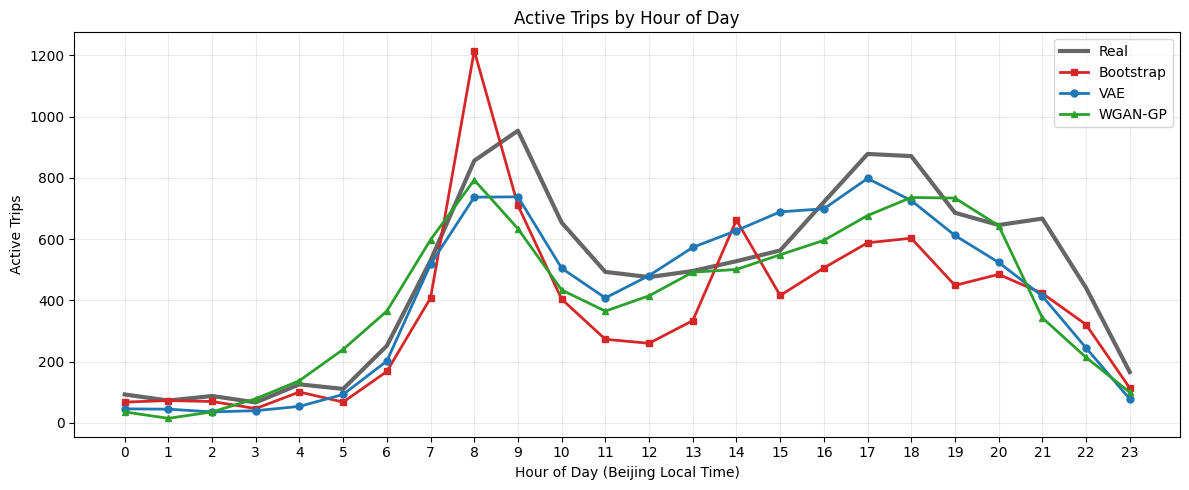

In [38]:
# =====================================================
# Active trips by hour: Real vs Seed111 models
# Synthetic hour shifted UTC -> Beijing local time
# =====================================================

MODELS = {
    "Bootstrap": "artifacts_v4/Bootstrap/bootstrap_seed111.csv",
    "VAE": "artifacts_v4/VAE/vae_seed111.csv",
    "WGAN-GP": "artifacts_v4/WGAN_GP/wgan_gp_seed111.csv",
}

UTC_TO_BEIJING_OFFSET = 8

def active_hour_counts_real(real_df):
    temp = real_df.copy()
    temp["start_time"] = pd.to_datetime(temp["start_time"], errors="coerce")
    temp["end_time"] = pd.to_datetime(temp["end_time"], errors="coerce")

    counts = np.zeros(24)

    for _, row in temp.dropna(subset=["start_time", "end_time"]).iterrows():
        start_hour = row["start_time"].hour
        end_hour = row["end_time"].hour

        if row["end_time"].date() == row["start_time"].date():
            active_hours = range(start_hour, end_hour + 1)
        else:
            active_hours = list(range(start_hour, 24)) + list(range(0, end_hour + 1))

        for h in active_hours:
            counts[h] += 1

    return counts


def active_hour_counts_real(real_df, offset=8):

    temp = real_df.copy()

    temp["start_time"] = pd.to_datetime(temp["start_time"])
    temp["end_time"] = pd.to_datetime(temp["end_time"])

    counts = np.zeros(24)

    for _, row in temp.iterrows():

        start_hour = (row["start_time"].hour + offset) % 24
        end_hour   = (row["end_time"].hour + offset) % 24

        if end_hour >= start_hour:
            active_hours = range(start_hour, end_hour + 1)
        else:
            active_hours = list(range(start_hour, 24)) + list(range(0, end_hour + 1))

        for h in active_hours:
            counts[h] += 1

    return counts


# -----------------------------
# Build plot table
# -----------------------------
hour_df = pd.DataFrame({
    "hour": range(24),
    "Real": active_hour_counts_real(df, offset=8)
})

for model_name, path in MODELS.items():
    synth_df = pd.read_csv(path)
    hour_df[model_name] = active_hour_counts_synth(
        synth_df,
        offset=UTC_TO_BEIJING_OFFSET
    )

# Optional: normalise to compare shape rather than total trip volume
for col in ["Real", "Bootstrap", "VAE", "WGAN-GP"]:
    hour_df[col + "_share"] = hour_df[col] / hour_df[col].sum()

COLOURS = {
    "Bootstrap": "#d62728",
    "VAE": "#1f77b4",
    "WGAN-GP": "#2ca02c",
    "Real": "black"
}

MARKERS = {
    "Bootstrap": "s",   # square
    "VAE": "o",         # circle
    "WGAN-GP": "^",     # triangle
    "Real": None
}


plt.figure(figsize=(12, 5))

plt.plot(
    hour_df["hour"],
    hour_df["Real"],
    color="black",
    linewidth=3,
    alpha=0.6,
    label="Real"
)

for model in ["Bootstrap", "VAE", "WGAN-GP"]:
    plt.plot(
        hour_df["hour"],
        hour_df[model],
        color=COLOURS[model],
        marker=MARKERS[model],
        markersize=5,
        linewidth=2,
        label=model
    )

plt.title("Active Trips by Hour of Day")
plt.xlabel("Hour of Day (Beijing Local Time)")
plt.ylabel("Active Trips")
plt.xticks(range(24))
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# MODELS

In [11]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = pipeline.transform(main_train_df)          # scaled feature DataFrame

X_np        = X.values.astype("float32")
D           = X_np.shape[1]                    # input_dim
n_real      = len(X_np)
real_scaled = X                                # scaled real features (for the collapse check)

# train/val split so the loss curves have a val line
X_tr, X_val = train_test_split(X_np, test_size=0.1, random_state=0)
train_loader = DataLoader(TensorDataset(torch.tensor(X_tr,  dtype=torch.float32)),
                          batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32)),
                          batch_size=64, shuffle=False)

## VAE

In [48]:
vae_model_params = {"latent_dim": 8, "lr": 1e-3, "beta": 0.05}      # beta from your sweep
vae_train_params = {"epochs": 100, "batch_size": 64, "val_size": 0.1,
                    "random_state": 0, "kl_warmup_frac": 0.4}

In [49]:
from src.evaluation.v4_metrics import od_flow_jsd

for beta in [0.01, 0.05, 0.1]:
    vae  = VAEModel(input_dim=D, latent_dim=8, beta=beta)
    hist = vae.fit(train_loader, val_loader, epochs=80, kl_warmup_frac=0.4)
    synth = vae.generate(n_real)
    std_ratio = synth.std().mean() / real_scaled.std().mean()   # your collapse check


    synth_scaled = vae.generate(n_real)
    synth_scaled.columns = X.columns            # VAEModel.generate emits 0..D-1; restore feature names
    synth_df = pipeline.inverse_transform(synth_scaled)   # back to real OD coordinates

    res   = od_flow_jsd(main_train_df, synth_df)          # h3_res=6 by default
    od_js = res["od_flow_js_distance"]
    print(f"beta={beta}: std_ratio={std_ratio:.2f}, recon={hist['recon'][-1]:.4f}, od_js={od_js:.3f}")

Training VAE:   0%|          | 0/80 [00:00<?, ?it/s]

beta=0.01: std_ratio=0.88, recon=0.0233, od_js=0.714


Training VAE:   0%|          | 0/80 [00:00<?, ?it/s]

beta=0.05: std_ratio=0.89, recon=0.0465, od_js=0.681


Training VAE:   0%|          | 0/80 [00:00<?, ?it/s]

beta=0.1: std_ratio=0.86, recon=0.0663, od_js=0.661


In [ ]:
# final selected parameters
vae_model_params = {"latent_dim": 8, "lr": 1e-3, "beta": 0.1}
vae_train_params = {"epochs": 80, "batch_size": 64, "val_size": 0.1,
                    "random_state": 0, "kl_warmup_frac": 0.4}

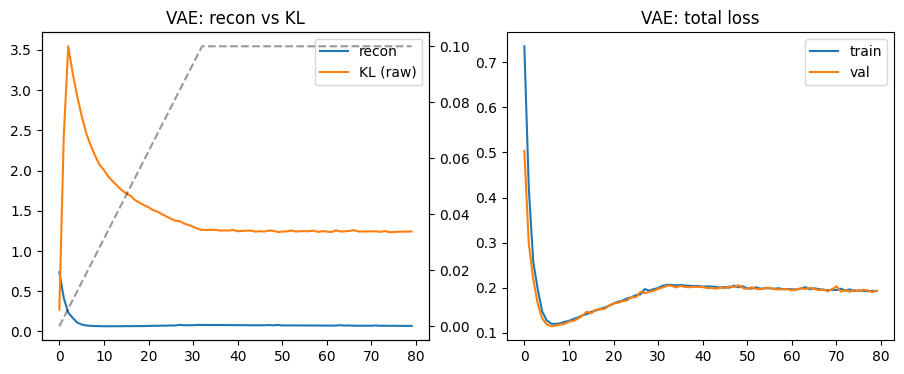

In [46]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["recon"], label="recon"); ax[0].plot(hist["kl"], label="KL (raw)")
ax2 = ax[0].twinx(); ax2.plot(hist["beta"], "k--", alpha=.4, label="beta")  # schedule overlay
ax[0].set_title("VAE: recon vs KL"); ax[0].legend(loc="upper right")
ax[1].plot(hist["loss"], label="train"); ax[1].plot(hist["val_loss"], label="val")
ax[1].set_title("VAE: total loss"); ax[1].legend()

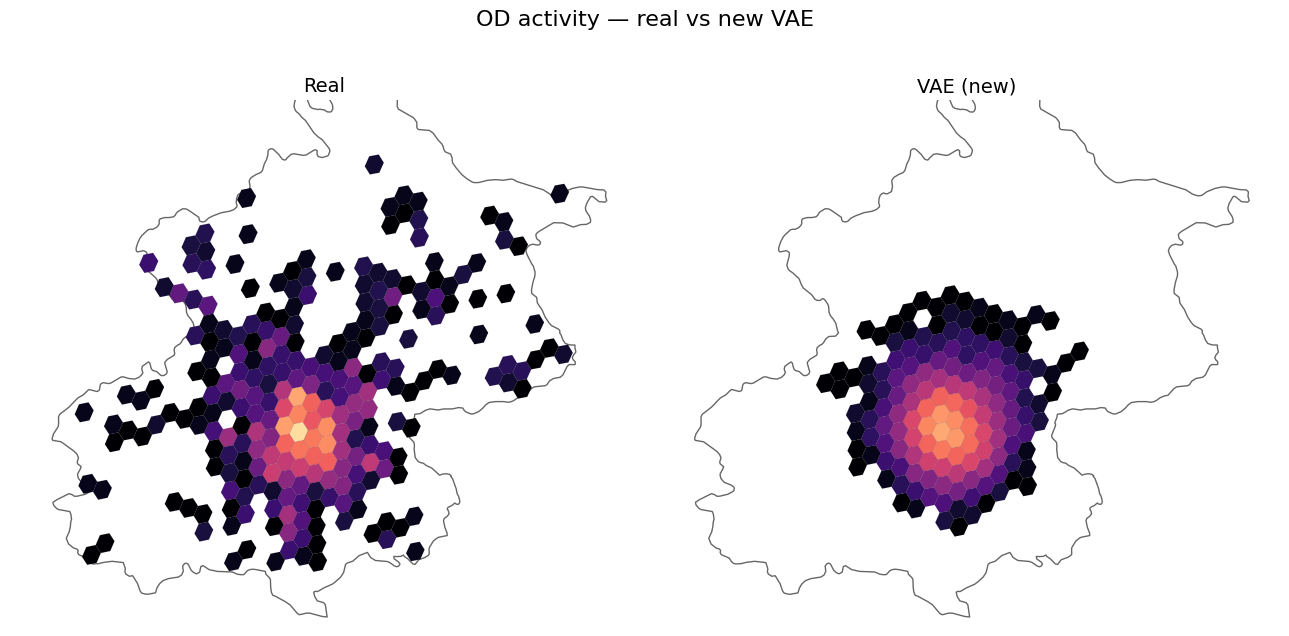

In [45]:
# assumes build_h3_activity, beijing_web, NORM, xlim, ylim, real_gdf are already defined
# from running the config / helper / boundary parts of your grid cell.
# synth_df = the inverse-transformed VAE output from the sweep cell.

# guard: the VAE can emit out-of-range coords; h3.latlng_to_cell needs valid lat/lon
ok = (
    synth_df["start_centroid_lat"].between(-90, 90)
    & synth_df["end_centroid_lat"].between(-90, 90)
    & synth_df["start_centroid_lon"].between(-180, 180)
    & synth_df["end_centroid_lon"].between(-180, 180)
)
synth_clean = synth_df[ok].copy()
dropped = len(synth_df) - len(synth_clean)
if dropped:
    print(f"dropped {dropped} synthetic trips with out-of-range coordinates")

synth_gdf = build_h3_activity(synth_clean, H3_RES)

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, gdf, title in [(axes[0], real_gdf, "Real"),
                       (axes[1], synth_gdf, "VAE (new)")]:
    beijing_web.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1, alpha=0.6)
    gdf.plot(column="log_activity", ax=ax, cmap="magma", norm=NORM,
             edgecolor="black", linewidth=0.05)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_axis_off()
    ax.set_title(title, fontsize=14)

fig.suptitle("OD activity — real vs new VAE", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## GAN

In [12]:
wgan_model_params = {"noise_dim": 64, "hidden_dim": 128, "lambda_gp": 10.0, "critic_steps": 3}
wgan_train_params = {"epochs": 100, "batch_size": 64, "val_size": 0.1, "random_state": 0}

# push to 200 or 300+ and watch where it plateaus.

# noise_dim — secondary. 64 is large for ~10 output features; if critic_steps doesn't move coverage, try 16 or 32 for a cleaner mapping.

In [ ]:
from src.evaluation.v4_metrics import od_flow_jsd
from src.models.wgan_gp import WGANModel

for hidden_dim in [128]:#, 5, 10]:
    wgan = WGANModel(input_dim=D, noise_dim=64, hidden_dim=hidden_dim,
                     lambda_gp=10.0, critic_steps=3)
    hist = wgan.fit(train_loader, epochs=100) # push to 200 or 300+ and watch where it plateaus.

    synth_scaled = wgan.generate(n_real)                  # scaled space
    std_ratio = synth_scaled.std().mean() / real_scaled.std().mean()

    synth_scaled.columns = X.columns                      # restore feature names
    synth_df = pipeline.inverse_transform(synth_scaled)
    res = od_flow_jsd(main_train_df, synth_df)

    print(f"hidden_dim={hidden_dim}: std_ratio={std_ratio:.2f}, "
          f"od_js={res['od_flow_js_distance']:.3f}, "
          f"coverage={res['od_flow_coverage']:.2f}, "
          f"c_loss={hist['c_loss'][-1]:.3f}")

Training WGAN-GP:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

c = pd.Series(hist["c_loss"])
g = pd.Series(hist["g_loss"])
w = 5  # rolling window to see the trend through GAN noise

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(c, alpha=0.3, color="C0")
ax[0].plot(c.rolling(w, min_periods=1).mean(), color="C0", label=f"critic (rolling {w})")
ax[0].axhline(0, ls=":", color="grey", alpha=0.5)
ax[0].set_title("WGAN: critic loss"); ax[0].set_xlabel("epoch"); ax[0].legend()

ax[1].plot(g, alpha=0.3, color="C1")
ax[1].plot(g.rolling(w, min_periods=1).mean(), color="C1", label=f"generator (rolling {w})")
ax[1].set_title("WGAN: generator loss"); ax[1].set_xlabel("epoch"); ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# assumes build_h3_activity, beijing_web, NORM, xlim, ylim, real_gdf are already defined
# from running the config / helper / boundary parts of your grid cell.
# synth_df = the inverse-transformed VAE output from the sweep cell.

# guard: the VAE can emit out-of-range coords; h3.latlng_to_cell needs valid lat/lon
ok = (
    synth_df["start_centroid_lat"].between(-90, 90)
    & synth_df["end_centroid_lat"].between(-90, 90)
    & synth_df["start_centroid_lon"].between(-180, 180)
    & synth_df["end_centroid_lon"].between(-180, 180)
)
synth_clean = synth_df[ok].copy()
dropped = len(synth_df) - len(synth_clean)
if dropped:
    print(f"dropped {dropped} synthetic trips with out-of-range coordinates")

synth_gdf = build_h3_activity(synth_clean, H3_RES)

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, gdf, title in [(axes[0], real_gdf, "Real"),
                       (axes[1], synth_gdf, "new")]:
    beijing_web.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1, alpha=0.6)
    gdf.plot(column="log_activity", ax=ax, cmap="magma", norm=NORM,
             edgecolor="black", linewidth=0.05)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_axis_off()
    ax.set_title(title, fontsize=14)

fig.suptitle("OD activity — real vs new", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
# 60

In [ ]:
# assumes build_h3_activity, beijing_web, NORM, xlim, ylim, real_gdf are already defined
# from running the config / helper / boundary parts of your grid cell.
# synth_df = the inverse-transformed VAE output from the sweep cell.

# guard: the VAE can emit out-of-range coords; h3.latlng_to_cell needs valid lat/lon
ok = (
    synth_df["start_centroid_lat"].between(-90, 90)
    & synth_df["end_centroid_lat"].between(-90, 90)
    & synth_df["start_centroid_lon"].between(-180, 180)
    & synth_df["end_centroid_lon"].between(-180, 180)
)
synth_clean = synth_df[ok].copy()
dropped = len(synth_df) - len(synth_clean)
if dropped:
    print(f"dropped {dropped} synthetic trips with out-of-range coordinates")

synth_gdf = build_h3_activity(synth_clean, H3_RES)

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, gdf, title in [(axes[0], real_gdf, "Real"),
                       (axes[1], synth_gdf, "new")]:
    beijing_web.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1, alpha=0.6)
    gdf.plot(column="log_activity", ax=ax, cmap="magma", norm=NORM,
             edgecolor="black", linewidth=0.05)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_axis_off()
    ax.set_title(title, fontsize=14)

fig.suptitle("OD activity — real vs new", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
from src.evaluation.v4_metrics import od_flow_jsd
from src.models.wgan_gp import WGANModel

for hidden_dim in [128]:#, 5, 10]:
    wgan = WGANModel(input_dim=D, noise_dim=64, hidden_dim=hidden_dim,
                     lambda_gp=10.0, critic_steps=3)
    hist = wgan.fit(train_loader, epochs=60) # push to 200 or 300+ and watch where it plateaus.

    synth_scaled = wgan.generate(n_real)                  # scaled space
    std_ratio = synth_scaled.std().mean() / real_scaled.std().mean()

    synth_scaled.columns = X.columns                      # restore feature names
    synth_df = pipeline.inverse_transform(synth_scaled)
    res = od_flow_jsd(main_train_df, synth_df)

    print(f"hidden_dim={hidden_dim}: std_ratio={std_ratio:.2f}, "
          f"od_js={res['od_flow_js_distance']:.3f}, "
          f"coverage={res['od_flow_coverage']:.2f}, "
          f"c_loss={hist['c_loss'][-1]:.3f}")